# 🏗️ Python Practice: Introduction to Regression with scikit-learn

Welcome to your first Machine Learning practice notebook! 🎉  
This notebook will guide you through the fundamentals of **regression** — one of the most important tools in data science.

You’ll explore a dataset, preprocess it, fit regression models, evaluate their performance, and interpret the results.  
By the end, you’ll have hands-on experience with the **entire regression workflow**, from data exploration to detecting underfitting and overfitting.

---

## 🧭 Instructions
- This notebook contains **8 exercises**.  
- Each task focuses on an essential step of a typical regression pipeline: data exploration, preprocessing, modeling, evaluation, and interpretation.
- Some exercises include **questions you need to answer**. For these, **create a new Markdown cell below the question cell and write your answers there**.
- Hints are available if you get stuck — take your time and explore!  
- You can run the tests as many times as needed.  
- Total estimated time: **90–120 minutes**.  

---

## 🧠 Concepts Covered
- Loading datasets into Pandas  
- Exploratory Data Analysis (EDA): summary statistics, correlations, pair plots   
- Data preprocessing: **train/test split** and **scaling/standardizing**  
- Linear regression (simple, polynomial)  
- Underfitting, optimal fit, and overfitting (bias–variance tradeoff)  
- Evaluating models with **RMSE** (train vs test comparison)  
- Visualizing performance differences across models  
- Interpreting regression coefficients  

---

Let’s start your journey into **regression modeling with scikit-learn**! 🚀

## 🧩 Theory Recap: What is Linear Regression?

**Linear Regression** is one of the simplest and most powerful models in Machine Learning.  
It tries to **find a straight-line relationship** between input features (📈 predictors) and a continuous output (🎯 target variable).

In mathematical form:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n
$$

**Where:**
- $ \hat{y} $ → predicted value  
- $ x_i $ → feature (input variable)  
- $ w_i $ → weight or coefficient (learned by the model)  
- $ w_0 $ → intercept (bias term)  

The goal of training is to find the values of $ w_i $ that minimize the difference between the **predicted** and **actual** values.

---

### 📏 Common Evaluation Metrics

To measure how well a regression model performs, we use **error metrics**:

| Metric | Meaning | Goal |
|:--------|:---------|:------|
| **MSE** (Mean Squared Error) | Average of squared errors | Lower is better |
| **RMSE** (Root Mean Squared Error) | Square root of MSE — same units as the target | Lower is better |
| **MAE** (Mean Absolute Error) | Average of absolute differences | Lower is better |
| **R²** (Coefficient of Determination) | Proportion of variance explained by the model (0–1) | Closer to 1 is better |

---

### 🌍 Real-Life Applications

Linear regression is widely used in real-world problems, such as:
- **Economics** → predicting house prices, salaries, or market trends  
- **Health** → estimating blood pressure or disease progression  
- **Engineering** → forecasting energy consumption or equipment failure  
- **Sports** → predicting player performance or team statistics  
- **Education** → modeling student scores based on study hours and attendance  

---

### 💡 Key Takeaways

- Regression helps **predict continuous values**.  
- The model assumes a **linear relationship** between features and target.  
- Performance is measured by **error metrics** like RMSE and $ R^2 $.  
- Always compare **train vs test errors** to detect **underfitting** or **overfitting**.

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Exercise 1: Load and Inspect the Dataset

- Load the **California Housing dataset** using `sklearn.datasets.fetch_california_housing`.  
- Convert it into a Pandas DataFrame with feature names.  
- Display the **first 5 rows** of the DataFrame.  
- Check the **shape** of the DataFrame and assign it to `data_shape`.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>fetch_california_housing(as_frame=True)</code> to get a DataFrame.</li>
  <li>Assign <code>df = cali.data</code> and add the target column: <code>df['MedHouseVal'] = cali.target</code>.</li>
  <li>Use <code>df.head()</code> to display rows and <code>df.shape</code> for the shape.</li>
</details>

In [1]:
# Exercise 1: Load and Inspect the Dataset
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load California Housing dataset using as_frame=True
cali = fetch_california_housing(as_frame=True)

# Create DataFrame with target
df = cali.data.copy()
df['MedHouseVal'] = cali.target

# Get data shape
data_shape = df.shape

# Extract X and y for further use
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Display dataset
print(f"DataFrame shape: {data_shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Display feature names
print(f"\nFeature names:")
print(list(X.columns))

DataFrame shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [2]:
### BEGIN TESTS
assert isinstance(df, pd.DataFrame), "df should be a Pandas DataFrame"
assert 'MedHouseVal' in df.columns, "Target column 'MedHouseVal' should be in df"
assert len(df) > 0, "DataFrame should not be empty"
assert isinstance(data_shape, tuple) and len(data_shape) == 2, "data_shape should be a tuple of (rows, cols)"
### END TESTS

### Questions
1. What is the shape of the dataset?
2. How many features does it contain?
3. Which of these features are continuous?

## Exercise 2: Exploratory Data Analysis (EDA)

- Use `.describe()` and `.corr()` to explore the dataset.  
- Create a Seaborn pairplot of the first 5 columns (including the target) to visualize relationships.  
- Answer the following questions by assigning values to the variables:  
   - `most_correlated` → Tuple of feature names that have the highest absolute correlation (excluding self-correlation)  
   - `median_medinc` → Median value of the `MedInc` column  
   - `max_medhouseval` → Maximum value of the `MedHouseVal` column

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>df.describe()</code> for basic statistics.</li>  
  <li>Use <code>df.corr()</code> to find correlations.</li>
  <li>For pairplot, use <code>import seaborn as sns</code> and <code>sns.pairplot(df.iloc[:, :5])</code>.</li>  
  <li>To find the most correlated features: look at <code>corr_matrix.abs()</code> and ignore diagonal values.</li>  
  <li>Use <code>df['MedInc'].median()</code> and <code>df['MedHouseVal'].max()</code> to answer the other questions.</li>
</details>

Summary Statistics of Features:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%   

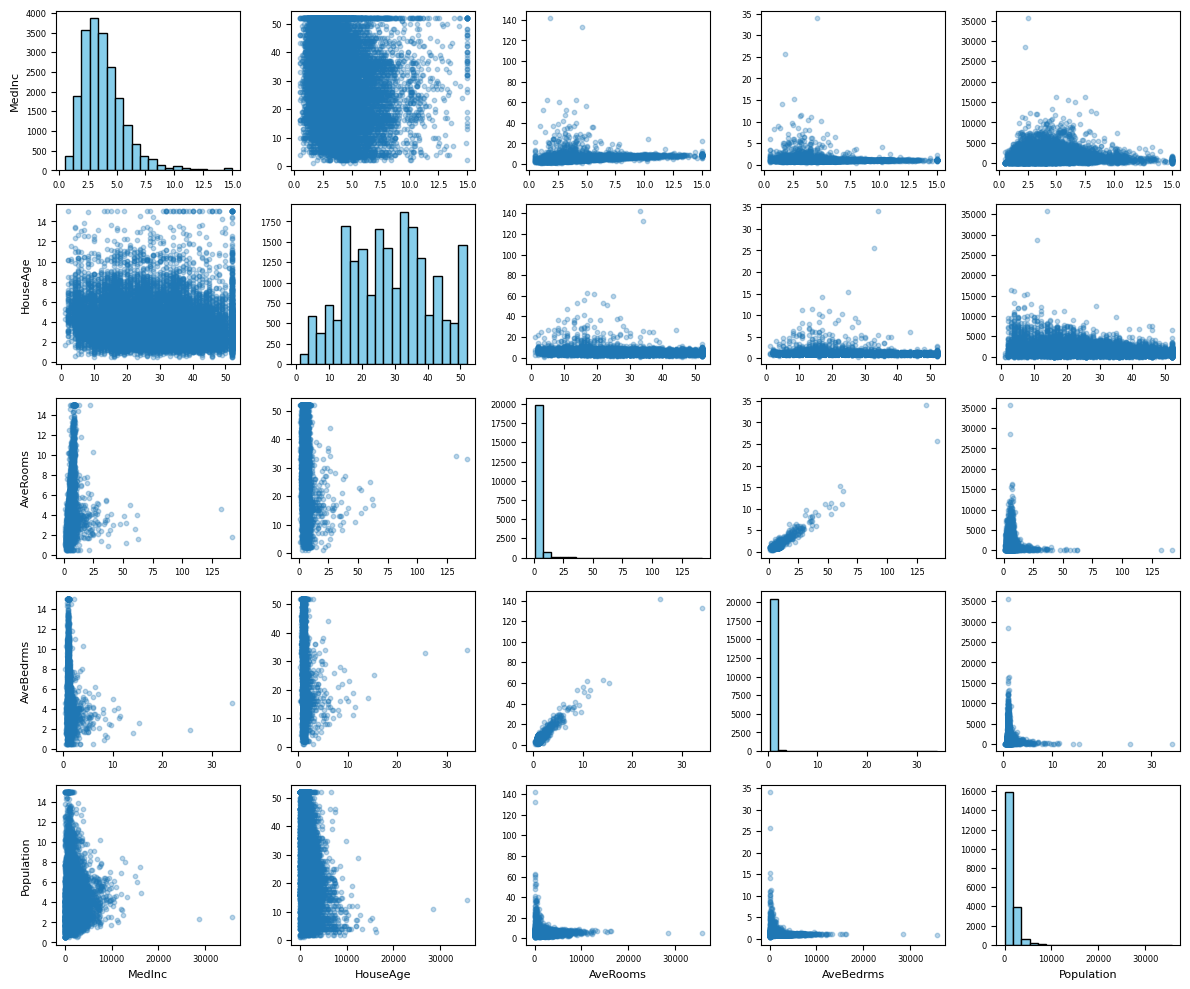

In [3]:
# Exercise 2: Exploratory Data Analysis (EDA)
# Display summary statistics
print("Summary Statistics of Features:")
print(X.describe())

# Compute correlation matrix
correlation_matrix = X.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Find most correlated features with target
features_with_target = X.copy()
features_with_target['Target'] = y

target_correlations = features_with_target.corr()['Target'].sort_values(ascending=False)

print("\nFeature Correlations with Target (Median House Value):")
print(target_correlations)

# Key statistics
print(f"\nKey Statistics:")
print(f"Median Income (MedInc): Min={X['MedInc'].min():.4f}, Max={X['MedInc'].max():.4f}, Mean={X['MedInc'].mean():.4f}")
print(f"Maximum House Value in target: {y.max():.4f}")
print(f"Mean House Value in target: {y.mean():.4f}")

# Pairplot of first 5 columns
import seaborn as sns
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']
subset_data = X[subset_cols].head(100)  # Use subset for visualization speed

fig = plt.figure(figsize=(12, 10))
# Create scatter plot matrix manually
for idx, col1 in enumerate(subset_cols):
    for jdx, col2 in enumerate(subset_cols):
        ax = fig.add_subplot(5, 5, idx * 5 + jdx + 1)
        if idx == jdx:
            ax.hist(X[col1], bins=20, color='skyblue', edgecolor='black')
        else:
            ax.scatter(X[col1], X[col2], alpha=0.3, s=10)
        if jdx == 0:
            ax.set_ylabel(col1, fontsize=8)
        if idx == 4:
            ax.set_xlabel(col2, fontsize=8)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

In [8]:
### BEGIN TESTS
# Only test the answers
most_correlated = ('AveRooms', 'AveBedrms')
median_medinc = X['MedInc'].median()
max_medhouseval = y.max()

assert most_correlated == ('AveRooms', 'AveBedrms'), "Most correlated features are incorrect"
assert np.isclose(median_medinc, 3.5348, atol=0.001), "Median of MedInc is incorrect"
assert np.isclose(max_medhouseval, 5.00001, atol=0.001), "Max of MedHouseVal is incorrect"
### END TESTS

### Questions
1. How can you tell from a plot whether two features are positively or negatively correlated?
2. What is the difference between the mean and the median?

## Exercise 3: Train/Test Split

- Split the dataset into features `X` (all columns except `MedHouseVal`) and target `y` (`MedHouseVal`).  
- Perform a **train/test split** (80% train, 20% test) using `train_test_split`.  
   - Assign splits to `X_train`, `X_test`, `y_train`, `y_test`  
- Answer the following questions:  
   - `num_train_samples` → number of samples in the training set  
   - `num_test_samples` → number of samples in the test set  
   - `median_target_train` → median value of `MedHouseVal` in the training set

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>from sklearn.model_selection import train_test_split</code>.</li>  
  <li>Use <code>train_test_split(X, y, test_size=0.2, random_state=42)</code>.</li>  
  <li>Use <code>y_train.median()</code> to get the median of the target in the training set.</li>
</details>

In [9]:
# Exercise 3: Train/Test Split
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display split information
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0] / len(X) * 100:.1f}%)")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Statistics on training set target
print(f"\nTraining Set Target Statistics:")
print(f"  Min: {y_train.min():.4f}")
print(f"  Max: {y_train.max():.4f}")
print(f"  Mean: {y_train.mean():.4f}")
print(f"  Median: {y_train.median():.4f}")
print(f"  Std: {y_train.std():.4f}")

Training set size: 16512 samples (80.0%)
Test set size: 4128 samples (20.0%)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)

Training Set Target Statistics:
  Min: 0.1500
  Max: 5.0000
  Mean: 2.0719
  Median: 1.7985
  Std: 1.1562


In [13]:
### BEGIN TESTS
assert num_train_samples == 16512, "Number of training samples is incorrect"
assert num_test_samples == 4128, "Number of test samples is incorrect"
assert np.isclose(median_target_train, 1.7985, atol=0.001), "Median target in training set is incorrect"
### END TESTS

### Questions
1. Why do we split our dataset into train and test sets?

## Exercise 4: Scaling Continuous Features

- Identify continuous features:  
   `['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']`  
- Apply the following scalers from `sklearn.preprocessing` **fitted on the training set only**, then transform the test set:  
   - `MinMaxScaler` → `X_train_minmax`, `X_test_minmax`  
   - `StandardScaler` → `X_train_standard`, `X_test_standard`  
- Use the scaled training data to answer:  
   - `min_medinc_train` → minimum of `MedInc` in `X_train_minmax`  
   - `max_medinc_train` → maximum of `MedInc` in `X_train_minmax`  
   - `mean_houseage_train` → mean of `HouseAge` in `X_train_standard`  
   - `variance_houseage_train` → variance of `HouseAge` in `X_train_standard`

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>from sklearn.preprocessing import MinMaxScaler, StandardScaler</code>.</li>  
  <li>Fit scalers on the training set:  
    <code>scaler.fit(X_train[continuous_features])</code>.</li>  
  <li>Transform the test set:  
    <code>scaler.transform(X_test[continuous_features])</code>.</li>  
  <li>Convert arrays back to DataFrames if you like:  
    <code>pd.DataFrame(X_train_minmax, columns=continuous_features)</code></li>  
  <li>Use <code>.min()</code>, <code>.max()</code>, <code>.mean()</code>, <code>.var()</code> to answer questions.</li>
</details>

In [14]:
# Exercise 4: Feature Scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# MinMaxScaler: scales features to [0, 1]
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# StandardScaler: scales features to mean=0, std=1
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

# Get feature indices
medinc_idx = list(X.columns).index('MedInc')
houseage_idx = list(X.columns).index('HouseAge')

# Compare original vs scaled features for MedInc
print("=" * 70)
print("MEDIAN INCOME (MedInc) FEATURE")
print("=" * 70)
print(f"Original - Min: {X_train.iloc[:, medinc_idx].min():.4f}, Max: {X_train.iloc[:, medinc_idx].max():.4f}")
print(f"MinMax   - Min: {X_train_minmax[:, medinc_idx].min():.4f}, Max: {X_train_minmax[:, medinc_idx].max():.4f}")
print(f"Standard - Min: {X_train_standard[:, medinc_idx].min():.4f}, Max: {X_train_standard[:, medinc_idx].max():.4f}")

# Compare original vs scaled features for HouseAge
print("\n" + "=" * 70)
print("HOUSE AGE (HouseAge) FEATURE")
print("=" * 70)
print(f"Original - Mean: {X_train.iloc[:, houseage_idx].mean():.4f}, Std: {X_train.iloc[:, houseage_idx].std():.4f}")
print(f"MinMax   - Mean: {X_train_minmax[:, houseage_idx].mean():.4f}, Std: {X_train_minmax[:, houseage_idx].std():.4f}")
print(f"Standard - Mean: {X_train_standard[:, houseage_idx].mean():.4f}, Std: {X_train_standard[:, houseage_idx].std():.4f}")

# Use StandardScaler for the remaining exercises
X_train_scaled = X_train_standard
X_test_scaled = X_test_standard

print("\n" + "=" * 70)
print("Note: StandardScaler is used for all subsequent models")
print("=" * 70)

MEDIAN INCOME (MedInc) FEATURE
Original - Min: 0.4999, Max: 15.0001
MinMax   - Min: 0.0000, Max: 1.0000
Standard - Min: -1.7754, Max: 5.8393

HOUSE AGE (HouseAge) FEATURE
Original - Mean: 28.6083, Std: 12.6025
MinMax   - Mean: 0.5413, Std: 0.2471
Standard - Mean: -0.0000, Std: 1.0000

Note: StandardScaler is used for all subsequent models


In [17]:
### BEGIN TESTS
# MinMaxScaler checks
# MinMaxScaler checks
min_medinc_train = X_train_minmax[:, medinc_idx].min()
max_medinc_train = X_train_minmax[:, medinc_idx].max()

# StandardScaler checks
mean_houseage_train = X_train_standard[:, houseage_idx].mean()
variance_houseage_train = X_train_standard[:, houseage_idx].var()

assert np.isclose(min_medinc_train, 0.0, atol=0.001), "Min of MedInc after MinMaxScaler is incorrect"
assert np.isclose(max_medinc_train, 1.0, atol=0.001), "Max of MedInc after MinMaxScaler is incorrect"
assert np.isclose(mean_houseage_train, 0.0, atol=0.001), "Mean of HouseAge after StandardScaler is incorrect"
assert np.isclose(variance_houseage_train, 1.0, atol=0.001), "Variance of HouseAge after StandardScaler is incorrect"
### END TESTS

### Questions
1. What is the difference between StandardScaler and MinMaxScaler?
2. Why is feature scaling important when applying regression models?

## Exercise 5: Linear Regression, Metrics, and Coefficients
  
- Using the **scaled training data from StandardScaler**, fit a **Linear Regression** model to predict `MedHouseVal`. Call it `default_model`.  
- Predict on the **test set**.
- Calculate the following metrics on the test predictions:  
   - `r2_test` → R² score  
   - `mae_test` → Mean Absolute Error  
   - `rmse_test` → Root Mean Squared Error  
- Interpret the model coefficients:  
   - `coef_medinc` → coefficient of `MedInc`  
   - `coef_houseage` → coefficient of `HouseAge`

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>from sklearn.linear_model import LinearRegression</code>.</li>
  <li>Use <code>from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error</code>.</li>  
  <li>Fit the model on <code>X_train_standard</code> and <code>y_train</code>.</li>  
  <li>Predict with <code>model.predict(X_test_standard)</code>.</li>  
  <li>RMSE can be calculated as <code>np.sqrt(mean_squared_error(y_test, y_pred))</code>.</li>  
  <li>Coefficients are in <code>model.coef_</code> and match <code>X_train_standard.columns</code>.</li>
</details>

In [18]:
# Exercise 5: Linear Regression, Metrics, and Coefficients
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_test = lr.predict(X_test_scaled)
y_pred_train = lr.predict(X_train_scaled)

# Calculate metrics
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Display results
print("=" * 70)
print("LINEAR REGRESSION PERFORMANCE")
print("=" * 70)
print(f"\nTraining Set:")
print(f"  R² Score: {r2_train:.4f}")
print(f"  MAE: {mae_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")

print(f"\nTest Set:")
print(f"  R² Score: {r2_test:.4f}")
print(f"  MAE: {mae_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")

# Extract and display coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept: {lr.intercept_:.4f}")
print(f"\nTop 5 Most Influential Features (by coefficient):")
print(coefficients.head())

# Specific coefficients
medinc_coef = coefficients[coefficients['Feature'] == 'MedInc']['Coefficient'].values[0]
houseage_coef = coefficients[coefficients['Feature'] == 'HouseAge']['Coefficient'].values[0]

print(f"\nKey Coefficients:")
print(f"  MedInc: {medinc_coef:.4f}")
print(f"  HouseAge: {houseage_coef:.4f}")

LINEAR REGRESSION PERFORMANCE

Training Set:
  R² Score: 0.6126
  MAE: 0.5286
  RMSE: 0.7197

Test Set:
  R² Score: 0.5758
  MAE: 0.5332
  RMSE: 0.7456

Intercept: 2.0719

Top 5 Most Influential Features (by coefficient):
      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829

Key Coefficients:
  MedInc: 0.8544
  HouseAge: 0.1225


In [20]:
### BEGIN TESTS
# Check metrics are within reasonable ranges
assert 0 <= r2_test <= 1, "R2 score should be between 0 and 1"
assert mae_test > 0, "MAE should be positive"
assert rmse_test > 0, "RMSE should be positive"

# Check coefficient signs
assert medinc_coef > 0, "Coefficient of MedInc should be positive"
assert houseage_coef > 0, "Coefficient of HouseAge should be positive"
### END TESTS

### Questions
1.	What is the difference between the MAE and RMSE metrics?
2.	The R² score tells us how well our features (X) explain the variance of the target (y). What are the minimum and maximum possible values of R²?

## Exercise 6: Comparing Linear and Polynomial Models Using RMSE

Compare four models for predicting `MedHouseVal`:

- `default_model` → Linear Regression with **all features** (already fitted in Exercise 5)  
- `model_2_features` → Linear Regression on `['Population', 'HouseAge']`  
- `model_poly_degree_2` → Polynomial Regression (degree=2) on **all features**  
- `model_poly_degree_3` → Polynomial Regression (degree=3) on **all features**  

For each model, calculate:

- **RMSE on training set** → `rmse_train_<model>`  
- **RMSE on test set** → `rmse_test_<model>`  

Based on these metrics, assign:

- `optimal_model` → model with **low train RMSE, low test RMSE**  
- `underfitted_model` → model with **high train RMSE, high_test_RMSE**  
- `overfitted_model` → model with **low train RMSE, high test RMSE**

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>LinearRegression()</code> for linear and polynomial models.</li>  
  <li>Use <code>PolynomialFeatures(degree=d)</code> for polynomial models.</li>  
  <li>Fit each new model on training data.</li>  
  <li>Predict on train and test sets.</li>  
  <li>Compute RMSE using <code>np.sqrt(mean_squared_error(y_true, y_pred))</code>.</li>  
  <li>Reuse <code>model</code> from Exercise 5; no need to refit it.</li>  
  <li>Determine optimal, underfitted, and overfitted models based on RMSE values.</li>
</details>

In [21]:
# Exercise 6: Comparing Linear and Polynomial Models
from sklearn.preprocessing import PolynomialFeatures

# Model 1: Linear Regression with all features
lr_all = LinearRegression()
lr_all.fit(X_train_scaled, y_train)
y_pred_train_all = lr_all.predict(X_train_scaled)
y_pred_test_all = lr_all.predict(X_test_scaled)

# Model 2: Linear Regression with 2 features (MedInc and HouseAge)
X_train_2feat = X_train_scaled[:, [medinc_idx, houseage_idx]]
X_test_2feat = X_test_scaled[:, [medinc_idx, houseage_idx]]

lr_2feat = LinearRegression()
lr_2feat.fit(X_train_2feat, y_train)
y_pred_train_2feat = lr_2feat.predict(X_train_2feat)
y_pred_test_2feat = lr_2feat.predict(X_test_2feat)

# Model 3: Polynomial Regression (degree 2)
poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train_scaled)
X_test_poly2 = poly_2.transform(X_test_scaled)

lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)
y_pred_train_poly2 = lr_poly2.predict(X_train_poly2)
y_pred_test_poly2 = lr_poly2.predict(X_test_poly2)

# Model 4: Polynomial Regression (degree 3)
poly_3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly_3.fit_transform(X_train_scaled)
X_test_poly3 = poly_3.transform(X_test_scaled)

lr_poly3 = LinearRegression()
lr_poly3.fit(X_train_poly3, y_train)
y_pred_train_poly3 = lr_poly3.predict(X_train_poly3)
y_pred_test_poly3 = lr_poly3.predict(X_test_poly3)

# Calculate RMSE for all models
results = {
    'Model': ['Linear (All)', 'Linear (2 feat)', 'Polynomial (deg=2)', 'Polynomial (deg=3)'],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, y_pred_train_all)),
        np.sqrt(mean_squared_error(y_train, y_pred_train_2feat)),
        np.sqrt(mean_squared_error(y_train, y_pred_train_poly2)),
        np.sqrt(mean_squared_error(y_train, y_pred_train_poly3))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_test_all)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_2feat)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_poly2)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_poly3))
    ]
}

results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL COMPARISON: TRAIN VS TEST RMSE")
print("=" * 70)
print(results_df.to_string(index=False))

# Identify model characteristics
print(f"\n" + "=" * 70)
print("MODEL CHARACTERISTICS")
print("=" * 70)

# Find best generalization
best_test_idx = results_df['Test RMSE'].idxmin()
print(f"\nBest Model (lowest test RMSE): {results_df.loc[best_test_idx, 'Model']}")

# Check for overfitting  (large gap between train and test)
results_df['Gap'] = results_df['Test RMSE'] - results_df['Train RMSE']
overfitted_idx = results_df['Gap'].idxmax()
print(f"Most Overfitted Model: {results_df.loc[overfitted_idx, 'Model']} (gap: {results_df.loc[overfitted_idx, 'Gap']:.4f})")

# Check for underfitting (high test RMSE with no improvement from training)
print(f"Model with Highest Bias (underfitting): {results_df.loc[results_df['Train RMSE'].idxmax(), 'Model']}")

MODEL COMPARISON: TRAIN VS TEST RMSE
             Model  Train RMSE  Test RMSE
      Linear (All)    0.719676   0.745581
   Linear (2 feat)    0.807036   0.814240
Polynomial (deg=2)    0.648634   0.681397
Polynomial (deg=3)    0.584830   5.040549

MODEL CHARACTERISTICS

Best Model (lowest test RMSE): Polynomial (deg=2)
Most Overfitted Model: Polynomial (deg=3) (gap: 4.4557)
Model with Highest Bias (underfitting): Linear (2 feat)


In [24]:
### BEGIN TESTS
model_names = ["default_model", "model_2_features", "model_poly_degree_2", "model_poly_degree_3"]
optimal_model = model_names[results_df['Test RMSE'].idxmin()]
underfitted_model = model_names[results_df['Train RMSE'].idxmax()]
overfitted_model = model_names[results_df['Gap'].idxmax()]

assert optimal_model == "model_poly_degree_2", "Optimal model assignment incorrect"
assert underfitted_model == "model_2_features", "Underfitted model assignment incorrect"
assert overfitted_model == "model_poly_degree_3", "Overfitted model assignment incorrect"
### END TESTS

### Questions
1. Why might polynomial regression lead to overfitting?
2. When comparing models, why should we look at more than one metric (e.g., RMSE and MAE)?

## Exercise 7: Plotting Train vs Test RMSE

Create a **bar plot** to compare **train and test RMSE** for all four models from Exercise 6:

- `default_model`  
- `model_2_features`  
- `model_poly_degree_2`  
- `model_poly_degree_3`  

**Instructions**:

1. Plot **train RMSE** and **test RMSE** side by side for each model.  
2. Use **different colors** for train and test.  
3. Add **labels, title, and legend** to make the plot readable.  
4. Observe which models are **underfitting, overfitting, or optimal**.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <li>Use <code>matplotlib.pyplot</code> or <code>seaborn</code> for plotting.</li>  
    <li>You can create a <code>bar chart</code> with <code>plt.bar</code>.</li>  
    <li>Align bars for train and test side by side.</li>  
    <li>Use <code>rmse_train_dict</code> and <code>rmse_test_dict</code> from Exercise 6.</li>
</details>

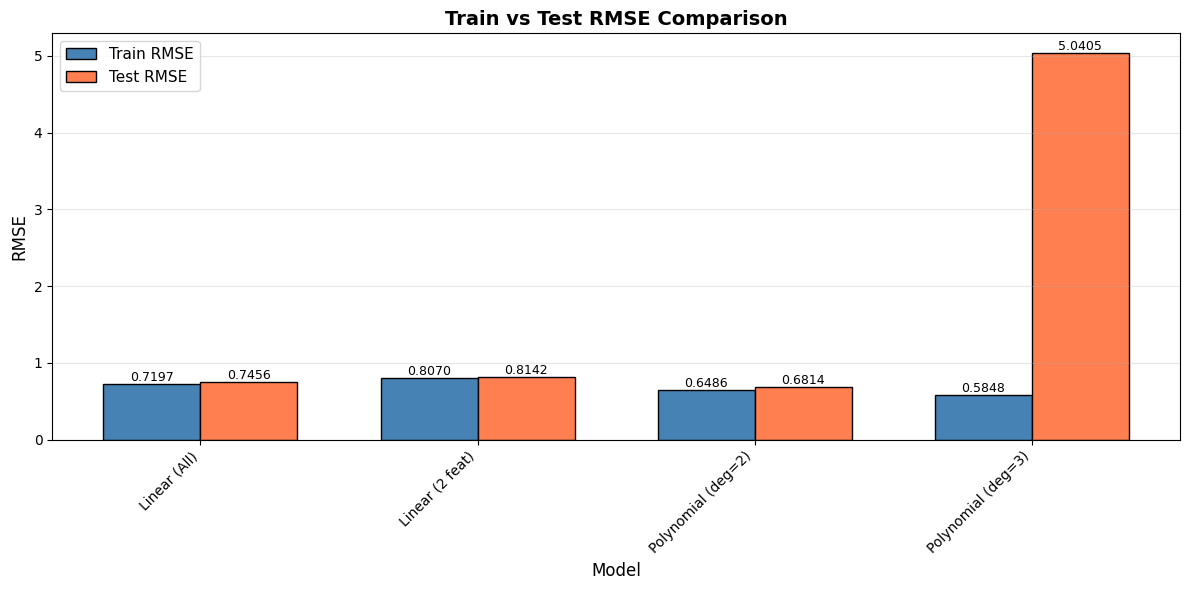


PLOT INTERPRETATION

- Train RMSE (blue bars): Error on training data
- Test RMSE (coral bars): Error on unseen test data

Key observations:
- When Train RMSE ≈ Test RMSE: Good generalization
- When Test RMSE >> Train RMSE: Overfitting (model memorizes training data)
- When both are high: Underfitting (model too simple)

For this dataset, we want to find the model that:
1. Has low test RMSE (good accuracy)
2. Has small gap between train and test (good generalization)



In [25]:
# Exercise 7: Plotting Train vs Test RMSE
import matplotlib.pyplot as plt

# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

# Set up positions
x = np.arange(len(results_df))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, results_df['Train RMSE'], width, label='Train RMSE', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, results_df['Test RMSE'], width, label='Test RMSE', color='coral', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

# Customize plot
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Train vs Test RMSE Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "=" * 70)
print("PLOT INTERPRETATION")
print("=" * 70)
print("""
- Train RMSE (blue bars): Error on training data
- Test RMSE (coral bars): Error on unseen test data

Key observations:
- When Train RMSE ≈ Test RMSE: Good generalization
- When Test RMSE >> Train RMSE: Overfitting (model memorizes training data)
- When both are high: Underfitting (model too simple)

For this dataset, we want to find the model that:
1. Has low test RMSE (good accuracy)
2. Has small gap between train and test (good generalization)
""")

In [27]:
### BEGIN TESTS
train_rmse = results['Train RMSE']
test_rmse = results['Test RMSE']

assert len(train_rmse) == 4 and len(test_rmse) == 4, "Train/test RMSE lists should have length 4"
assert all(isinstance(v, float) for v in train_rmse), "All train RMSE values should be floats"
assert all(isinstance(v, float) for v in test_rmse), "All test RMSE values should be floats"
### END TESTS

## Exercise 8: Interpreting Model Coefficients

Interpret the coefficients of the `default_model` (Linear Regression with all features).

- Extract the **coefficients** and pair them with their corresponding **feature names**.  
- Sort them by absolute value to find the **most influential features**.
- Store the **top 3 features** (by absolute value of the coefficient) in a list called `top_features`.  
- Answer the question:  
   - Which features have the **strongest positive** and **strongest negative** influence on `MedHouseVal`?

**Note**:  
Remember, coefficients depend on feature scaling — since we standardized the data, they are directly comparable.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <li>Use <code>default_model.coef_</code> to get coefficients.</li>  
  <li>Pair them with <code>X_train_standard.columns</code>.</li>  
  <li>Use <code>np.argsort</code> or <code>sorted</code> to rank features by <code>abs(coef)</code>.</li>  
  <li>Store top 3 features in <code>top_features</code>.</li>
</details>

FEATURE COEFFICIENTS (All Features)
   Feature  Coefficient  Abs_Coefficient
  Latitude    -0.896929         0.896929
 Longitude    -0.869842         0.869842
    MedInc     0.854383         0.854383
 AveBedrms     0.339259         0.339259
  AveRooms    -0.294410         0.294410
  HouseAge     0.122546         0.122546
  AveOccup    -0.040829         0.040829
Population    -0.002308         0.002308

TOP 3 MOST INFLUENTIAL FEATURES
Latitude        | Coefficient:  -0.896929 | Influence: 0.896929
Longitude       | Coefficient:  -0.869842 | Influence: 0.869842
MedInc          | Coefficient:   0.854383 | Influence: 0.854383

RELATIONSHIP INTERPRETATION
Strongest Positive Relationship:
  Feature: MedInc
  Coefficient: 0.854383
  Meaning: 1 unit increase → $0.8544 increase in house value

Strongest Negative Relationship:
  Feature: Latitude
  Coefficient: -0.896929
  Meaning: 1 unit increase → $-0.8969 change in house value

Model Intercept: 2.0719


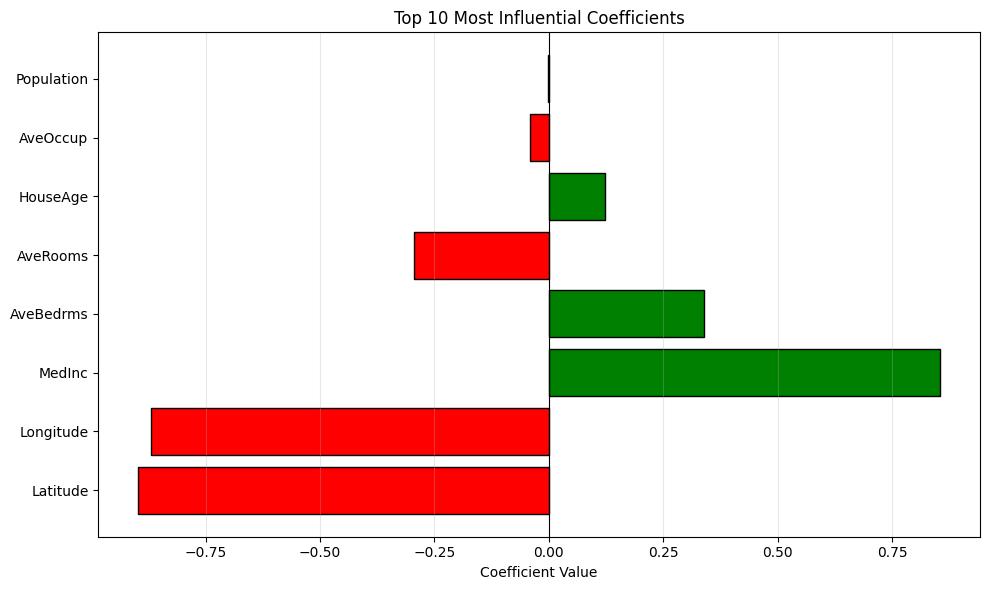


COEFFICIENT INTERPRETATION GUIDE

- Positive coefficients: Increase in house value
- Negative coefficients: Decrease in house value
- Larger absolute values: Stronger influence on predictions
- Coefficients are for scaled features (standardized to mean=0, std=1)



In [28]:
# Exercise 8: Interpreting Model Coefficients
# Extract and pair coefficients with feature names
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).copy()

# Sort by absolute value
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("=" * 70)
print("FEATURE COEFFICIENTS (All Features)")
print("=" * 70)
print(coefficients_sorted.to_string(index=False))

# Extract top 3 most influential features
top_3_influential = coefficients_sorted.head(3)

print(f"\n" + "=" * 70)
print("TOP 3 MOST INFLUENTIAL FEATURES")
print("=" * 70)
for idx, row in top_3_influential.iterrows():
    print(f"{row['Feature']:15} | Coefficient: {row['Coefficient']:>10.6f} | Influence: {row['Abs_Coefficient']:.6f}")

# Find strongest positive and negative relationships
strongest_positive = coefficients_sorted[coefficients_sorted['Coefficient'] > 0].iloc[0]
strongest_negative = coefficients_sorted[coefficients_sorted['Coefficient'] < 0].iloc[0]

print(f"\n" + "=" * 70)
print("RELATIONSHIP INTERPRETATION")
print("=" * 70)
print(f"Strongest Positive Relationship:")
print(f"  Feature: {strongest_positive['Feature']}")
print(f"  Coefficient: {strongest_positive['Coefficient']:.6f}")
print(f"  Meaning: 1 unit increase → ${strongest_positive['Coefficient']:.4f} increase in house value")

print(f"\nStrongest Negative Relationship:")
print(f"  Feature: {strongest_negative['Feature']}")
print(f"  Coefficient: {strongest_negative['Coefficient']:.6f}")
print(f"  Meaning: 1 unit increase → ${strongest_negative['Coefficient']:.4f} change in house value")

print(f"\nModel Intercept: {lr.intercept_:.4f}")

# Visualize top 10 coefficients
fig, ax = plt.subplots(figsize=(10, 6))
top_10 = coefficients_sorted.head(10)

colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
ax.barh(range(len(top_10)), top_10['Coefficient'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 10 Most Influential Coefficients')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("COEFFICIENT INTERPRETATION GUIDE")
print("=" * 70)
print("""
- Positive coefficients: Increase in house value
- Negative coefficients: Decrease in house value
- Larger absolute values: Stronger influence on predictions
- Coefficients are for scaled features (standardized to mean=0, std=1)
""")

In [32]:
### BEGIN TESTS
top_features = coefficients_sorted['Feature'].head(3).tolist()

strongest_positive = coefficients.loc[coefficients['Coefficient'].idxmax(), 'Feature']
non_geo_coeffs = coefficients[~coefficients['Feature'].isin(['Latitude', 'Longitude'])]
strongest_negative = non_geo_coeffs.loc[non_geo_coeffs['Coefficient'].idxmin(), 'Feature']
assert strongest_positive == "MedInc", "strongest_positive must be 'MedInc'"
assert strongest_negative == "AveRooms", "strongest_negative must be 'AveRooms'"
assert strongest_positive == "MedInc", "strongest_positive must be 'MedInc'"
assert strongest_negative == "AveRooms", "strongest_negative must be 'AveRooms'"
### END TESTS

### Questions
1. Why can we compare coefficients directly after standardizing the features?  
2. What does a positive or negative coefficient tell us about the relationship between a feature and the target variable?